# Unit 3 Assessment - Empirical Models

## Instructions

In this assessment, you are going to develop an emperical model by fitting a curve to data, and you will use your model to make predictions.

Scores are determined by:

- Successfully starting the C Level = 50 pts
- Perfectly completing the C Level = 75 pts
- Perfectly completing the B and C Levels = 85 pts
- Perfectly completing the A, B, and C Levels = 100 pts

You may use your Colab notebooks, our textbook, my notebook solutions, and any links to web sites I provide. (You may not use any other person or web site or book or resource, in general.) 

You may ask me for help **once**; however, you may ask for clarification as often as needed.

Add additional cells for both code and markdown as needed. **Write answers to questions in narrative form in markdown.** You may print values you need in your code, and then use these values in a written response.

**All graphs should have correct titles and axis labels (with units).**

**All number should have proper units**

### **Using resources**

You may use your Colab notebooks from class, any other notebook or reading I have given you, and any links to web sites I have provided. Basically, if it is linked on Blackboard then you can use it.

You may not use any other person, website, book, or resource. This includes the AI features in Google Colab or any other generative AI tool (ChatGPT, etc.) You are responsible for using only approved resources. If you're unsure whether something is allowed, please ask me before using it.

You can disable the Gemini AI assistance by going to settings and unchecking `Show AI-powered inline completions` and `Consented to use generative AI features` and checking `Hide generative AI features.` as seen below.

### **Citing Sources**

Citing sources isn't just about copying and pasting code—it's about giving credit whenever you use ideas, inspiration, or guidance from another source, even if you don't copy directly. Here's how to handle it:

- **When to Cite**:
  - If you refer to a **specific code example** from class materials, notebooks, or a reading.
    - Example: "I used the loop structure from the `02-01-random` notebook, exercise 1."
  - When you use an **idea** or approach that you didn't come up with on your own, even if you modify it.
    - Example: "The way I calculated the probability of finding the area of a circle was based on the pre-class notebook for Day 3."
  - **Even if you don't copy-paste** code, if something influenced your thinking or the way you structured your solution, it should be cited.
  
- **What doesn't need citation**:
  - Basic ideas that come entirely from your own brain.
  - Simple language constructs like loops, if-statements, or variables, unless they come directly from an example you're referencing.

- **Key points**
  - It's always better to cite than to leave something out. You won't lose points for over-citing and I will give you feedback on what citations are required or not.
  - Don't just cite when you copy code—cite when ideas or problem-solving approaches come from an outside source.

- **Examples of Correct Citations**:
  - **Copied/Modified Code**: "We used the code from the `randomwalk1D` function in the `02-03-random-walk` notebook to help structure our loop."
  - **Concept or Inspiration**: "We based our approach for determining the circle a dart landed in on the exmaple we did in class estimating $\pi$. "

## Grade

<font color="green"></font>

Level | Grade | Comment
--- | --- | ---
C (75 pts) | | 
B (10 pts) | | 
A (15 pts) | | 
Total | 


# Level C

## Exercise 0

1. Save a copy of this notebook to Google Drive in the folder you have shared with me. 

2. Add a text cell above and type your name as a level one heading in markdown. (A level one heading starts with # on its own line.)

3. Run the `import` statements below to add packages.

In [1]:
import numpy as np #used for arrays and numerical functions
import pandas as pd #used for reading a data file
import matplotlib.pyplot as plt #used for graphing
from io import StringIO #used to convert string to a dataframe
from scipy.optimize import curve_fit #used to find the fit parameters

## Exercise 1

As the temperature of a solution increases, the amount of solute that can be dissolved increases. This [data set](https://raw.githubusercontent.com/anthoak13/HNR-1303-F24/F25/unit-03/03-10-problem/solubility.txt) ([source](https://pubs.acs.org/doi/10.1021/je00045a020)) shows the amount of sodium chloride (measured in g) that can be dissolved in 100 g of a particular water-based solvent. Read the data and graph the amount of sodium chloride that can be dissolved as a function of temperature.

   Temp (C)  NaCl Solubility (g)
0      27.0                26.76
1      30.0                26.79
2      40.0                27.28
3      40.0                27.86
4      50.0                26.89


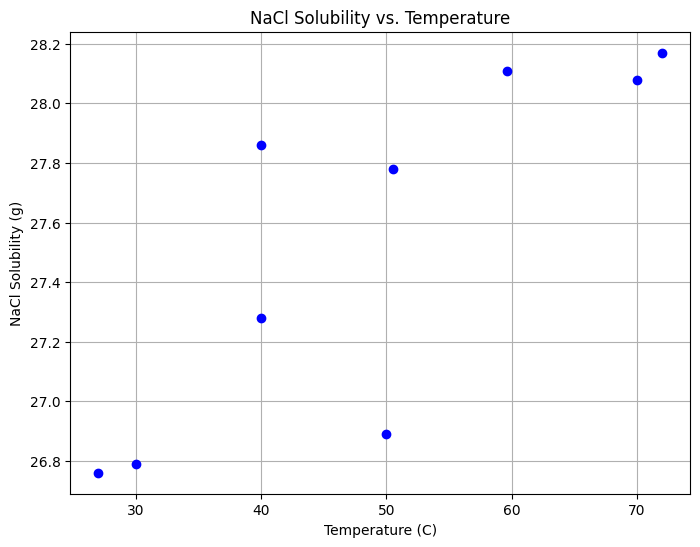

In [4]:
# convert data to dataframe
df = pd.read_csv("https://raw.githubusercontent.com/anthoak13/HNR-1303-F24/F25/unit-03/03-10-problem/solubility.txt", sep ="\t")

print(df.head())

# define arrays for the data
xdata = df['Temp (C)']
ydata = df['NaCl Solubility (g)']


# plot data and the best-fit function on the same graph
fig = plt.figure(figsize=(8,6))
plt.title("NaCl Solubility vs. Temperature")
plt.xlabel('Temperature (C)')
plt.ylabel('NaCl Solubility (g)')
plt.grid(which='both', axis='both')
plt.plot(xdata, ydata, 'bo') #plot data
plt.show()

## Exercise 2

Using the data from Exercise 1, perform a linear curve fit to model the relationship between temperature and NaCl solubility. Plot the best-fit line along with the original data on the same graph. Report the best-fit parameters for your model.

   Temp (C)  NaCl Solubility (g)
0      27.0                26.76
1      30.0                26.79
2      40.0                27.28
3      40.0                27.86
4      50.0                26.89
The slope is 0.0298 and the intercept is 26.0688


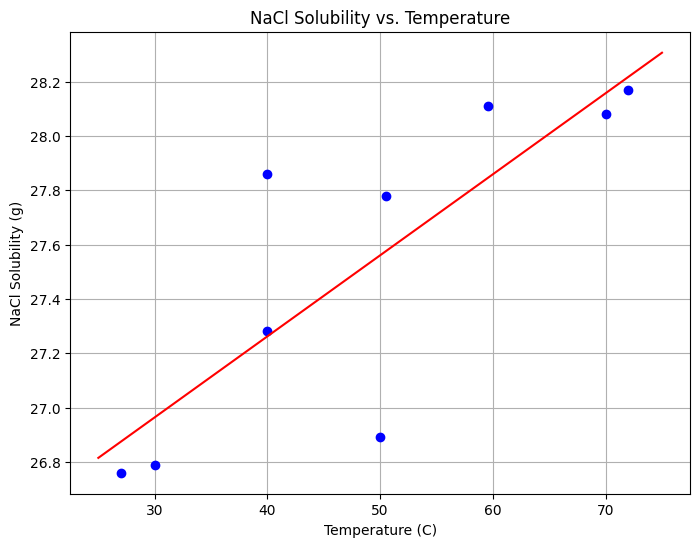

In [6]:
# convert data to dataframe
df = pd.read_csv("https://raw.githubusercontent.com/anthoak13/HNR-1303-F24/F25/unit-03/03-10-problem/solubility.txt", sep ="\t")

print(df.head())

# define arrays for the data
xdata = df['Temp (C)']
ydata = df['NaCl Solubility (g)']

# Define the best-fit function (model)
model = lambda x, m, b: m*x + b

# Fit the model to the data
guess = [1, 1]  # initial guess for m and b
params, cov = curve_fit(model, xdata, ydata, p0=guess)
print(f"The slope is {params[0]:.4f} and the intercept is {params[1]:.4f}")

# Generate the best-fit line using the fitted parameters
xmodel = np.linspace(25, 75, 1000)
ymodel = model(xmodel, *params)

# plot data and the best-fit function on the same graph
fig = plt.figure(figsize=(8,6))
plt.title("NaCl Solubility vs. Temperature")
plt.xlabel('Temperature (C)')
plt.ylabel('NaCl Solubility (g)')
plt.grid(which='both', axis='both')
plt.plot(xdata, ydata, 'bo') #plot data
plt.plot(xmodel, ymodel, 'r-') #plot best-fit line
plt.show()

The best fit parameters are a slope of 0.0298 g/C and an intercept of 26.0688 g.

## Exercise 3

Using your curve-fit, predict the amount of NaCl that can be dissolved at 0, 45, 80, and 100 $\text{C}^\circ$.

At 0 C, the predicted NaCl solubility is 26.07 g.

At 45 C, the predicted NaCl solubility is 27.41 g.

At 80 C, the predicted NaCl solubility is 28.46 g.

At 100 C, the predicted NaCl solubility is 29.05 g.


In [8]:
print(f"At 0 C, the predicted NaCl solubility is {model(0, *params):.2f} g")
print(f"At 45 C, the predicted NaCl solubility is {model(45, *params):.2f} g")
print(f"At 80 C, the predicted NaCl solubility is {model(80, *params):.2f} g")
print(f"At 100 C, the predicted NaCl solubility is {model(100, *params):.2f} g")


At 0 C, the predicted NaCl solubility is 26.07 g
At 45 C, the predicted NaCl solubility is 27.41 g
At 80 C, the predicted NaCl solubility is 28.46 g
At 100 C, the predicted NaCl solubility is 29.05 g


## Exercise 4

Evaluate the predictions you made in Exercise 3. Which predictions do you believe are valid, and why? For predictions that seem less accurate or reasonable, explain why you think this is the case. 

Only the prediction at 45 degrees Celsius is likely valid. Our data only covers bout 25 C to 75 C, so the rest of our data lies outside that range. Since this is an empirical model, we can only make predictions where we have data (interpolate).

# Level B

Two HPU alumni, Chris Schorn and Shane Wiess, tested a t-shirt launcher designed and constructed by alumnus Noah Novembre. Chris and Shane measured the exit speed of a t-shirt as a function of the air pressure in the barrel. This [file](https://raw.githubusercontent.com/anthoak13/HNR-1303-F24/F25/unit-03/03-10-problem//pressure-speed.txt) has their data.



## Exercise 1
Read the data and plot the exit speed of the t-shirt (when exiting the barrel) as a function of the air pressure in the barrel.

   P (psi)  v (m/s)
0       20     1.36
1       25     2.24
2       30     3.52
3       35     4.33
4       40     5.22


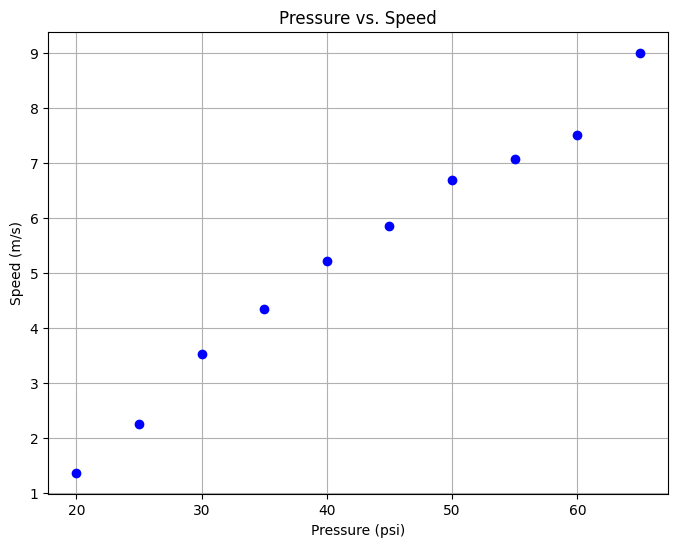

In [10]:
# convert data to dataframe
df = pd.read_csv("https://raw.githubusercontent.com/anthoak13/HNR-1303-F24/F25/unit-03/03-10-problem//pressure-speed.txt", sep ="\t")
print(df.head())

# define arrays for the data
xdata = df['P (psi)']
ydata = df['v (m/s)']


# plot data and the best-fit function on the same graph
fig = plt.figure(figsize=(8,6))
plt.title("Pressure vs. Speed")
plt.xlabel('Pressure (psi)')
plt.ylabel('Speed (m/s)')
plt.grid(which='both', axis='both')
plt.plot(xdata, ydata, 'bo') #plot data
plt.show()

## Exercise 2

Fit a curve to the exit speed as a function of air pressure using a power law plus a constant, of the form:

$$y = Ax^n + B$$

where $y$ is the air pressure and $x$ is the exit speed. Report the values of the best-fit parameters, A and B, and plot the best-fit curve on the same graph as the data.

   P (psi)  v (m/s)
0       20     1.36
1       25     2.24
2       30     3.52
3       35     4.33
4       40     5.22
The fitted parameters are A = 2.2440, n = 0.4811, B = -8.1411


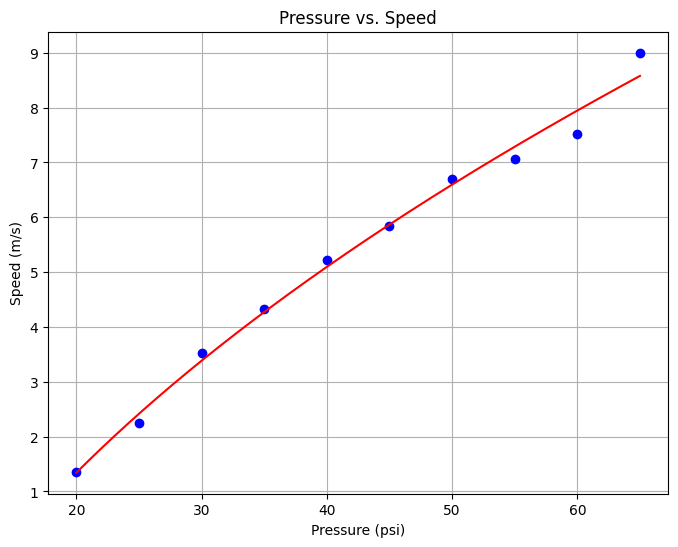

In [11]:
# convert data to dataframe
df = pd.read_csv("https://raw.githubusercontent.com/anthoak13/HNR-1303-F24/F25/unit-03/03-10-problem//pressure-speed.txt", sep ="\t")
print(df.head())

# define arrays for the data
xdata = df['P (psi)']
ydata = df['v (m/s)']

# Define the best-fit function (model)
model = lambda x, A, n, B: A * x**n + B

# Fit the model to the data
guess = [1, 1, 1]  # initial guess for A, n, and B
params, cov = curve_fit(model, xdata, ydata, p0=guess)
print(f"The fitted parameters are A = {params[0]:.4f}, n = {params[1]:.4f}, B = {params[2]:.4f}")

# Generate the best-fit line using the fitted parameters
xmodel = np.linspace(20, 65, 1000)
ymodel = model(xmodel, *params)

# plot data and the best-fit function on the same graph
fig = plt.figure(figsize=(8,6))
plt.title("Pressure vs. Speed")
plt.xlabel('Pressure (psi)')
plt.ylabel('Speed (m/s)')
plt.grid(which='both', axis='both')
plt.plot(xdata, ydata, 'bo') #plot data
plt.plot(xmodel, ymodel, 'r-') #plot best-fit line
plt.show()

The best fit parameters for our model are $A = 2.24 ~\text{m/s}\cdot\text{psi}^{0.48}$, $n = 0.48$, and $B=-8.14~\text{psi}$.

## Exercise 3

According to your model, what is the exit speed when the pressure is zero? 

Is this physically possible?


Our model predicts the exit speed to be -8.14 m/s at zero PSI. This is impossible for two reasons, first speed is always a positive number. Second, this implies that when there is no pressure in the cannon the t-shirt is somehow flying *backward*.

In [12]:
print(f"The exit speed at 0 psi is {model(0, *params):.2f} m/s")

The exit speed at 0 psi is -8.14 m/s


## Exercise 4

What is the minimum air pressure in the barrel in order for a t-shirt to exit the barrel (in other words, its exit speed is close to zero)?


Through guess and check, it seems the minimum pressure is about 14.5 psi.

In [17]:
pressure = 14.5
print(f"The exit speed at {pressure} psi is {model(pressure, *params):.2f} m/s")

The exit speed at 14.5 psi is -0.02 m/s


## Exercise 5

The barrel is composed of PVC that is rated for a maximum of 140 psi. At the maximum pressure for the barrel, what do you predict the exit speed of a t-shirt to be?

At the maximum pressure, we would predict the speed to be 16 m/s; however, this is not reliable since we have no data at that high a pressure 

In [18]:
pressure = 140
print(f"The exit speed at {pressure} psi is {model(pressure, *params):.2f} m/s")

The exit speed at 140 psi is 16.04 m/s


# Level A



In language, it is often the case that the most common word occurs about twice as often as the second most common word, about three times as often as the third most common word, etc. If we were to take every word in English and sort them by how frequently they occur, the *rank* of a word is its position in this ordered list. That is, the most common word has rank 1, the second most common has rank 2, etc. This [file](https://raw.githubusercontent.com/anthoak13/HNR-1303-F24/F25/unit-03/03-10-problem/english_words.txt) contains the 1500 most common words in English ranked by how frequently they occur. The data comes from scraping one million sentences off of websites with a ``.com`` domain ([source](https://wortschatz.uni-leipzig.de/en/download)).


## Exercise 1

Read the data into a `dataframe` and print the first few rows in the file using the `head()` function. Do not try to copy and paste the data (there is too much of it). What is the most common word in English? What is the second most common word in English?

The most common word in English is "the." The second most common word in English is "to."


In [20]:
# convert data to dataframe
df = pd.read_csv("https://raw.githubusercontent.com/anthoak13/HNR-1303-F24/F25/unit-03/03-10-problem/english_words.txt", sep ="\t")

print(df.head())



   Rank Word  Frequency
0     1  the     795170
1     2   to     504706
2     3  and     479484
3     4    a     416154
4     5   of     411095


## Exercise 2
Plot the frequency of words in English as a function of their rank.

   Rank Word  Frequency
0     1  the     795170
1     2   to     504706
2     3  and     479484
3     4    a     416154
4     5   of     411095


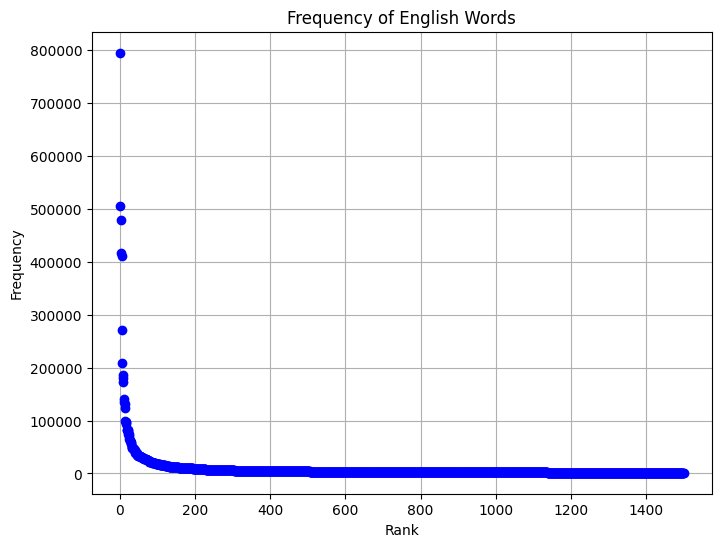

In [21]:
# convert data to dataframe
df = pd.read_csv("https://raw.githubusercontent.com/anthoak13/HNR-1303-F24/F25/unit-03/03-10-problem/english_words.txt", sep ="\t")

print(df.head())

# define arrays for the data
xdata = df['Rank']
ydata = df['Frequency']


# plot data and the best-fit function on the same graph
fig = plt.figure(figsize=(8,6))
plt.title("Frequency of English Words")
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.grid(which='both', axis='both')
plt.plot(xdata, ydata, 'bo') #plot data
plt.show()

## Exercise 3

Fit a curve to the frequency of words as a function of their rank using the following power law:

$$ y = \frac{A}{(x+B)^n}$$
where $y$ is the frequency of a word and $x$ is the rank of the word. A power law distribution of this form is known as a [Zipf-Mandelbrot law](https://en.wikipedia.org/wiki/Zipf%E2%80%93Mandelbrot_law). Report on the best-fit parameters ($A$, $B$, and $n$) and plot the best-fit curve on the same graph as the data.


   Rank Word  Frequency
0     1  the     795170
1     2   to     504706
2     3  and     479484
3     4    a     416154
4     5   of     411095
The fitted parameters are A = 2623446.1495, n = 1.0907, B = 2.0239


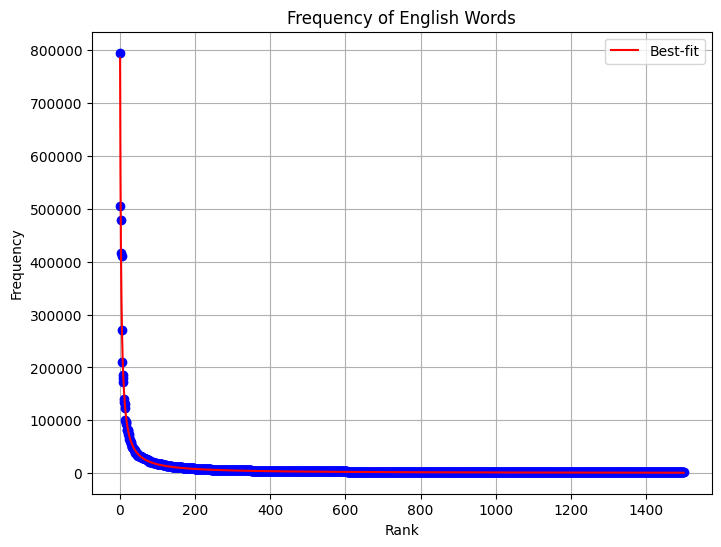

In [ ]:
# convert data to dataframe
df = pd.read_csv("https://raw.githubusercontent.com/anthoak13/HNR-1303-F24/F25/unit-03/03-10-problem/english_words.txt", sep ="\t")

print(df.head())

# define arrays for the data
xdata = df['Rank']
ydata = df['Frequency']

# Define the best-fit function (model)
model = lambda x, A, n, B: A / (x+ B)**n

# Fit the model to the data
guess = [10000, 1, 1]  # initial guess for A, n, and B. Guess A is large since when x is small, y is large
params, cov = curve_fit(model, xdata, ydata, p0=guess)
print(f"The fitted parameters are A = {params[0]:.4f}, n = {params[1]:.4f}, B = {params[2]:.4f}")

# Generate the best-fit line using the fitted parameters
xmodel = np.linspace(1, 1500, 10000)
ymodel = model(xmodel, *params)

# plot data and the best-fit function on the same graph
fig = plt.figure(figsize=(8,6))
plt.title("Frequency of English Words")
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.grid(which='both', axis='both')
plt.plot(xdata, ydata, 'bo') #plot data
plt.plot(xmodel, ymodel, 'r-', label='Best-fit')
plt.legend()
plt.show()

The best fit parameters as $A = 2623446.1495, n = 1.0907, B = 2.0239$. They are all unitless.

## Exercise 4
With the large spread of values on the y-axis, it is hard to see how well the model and data are agreeing at higher ranks. Fill in the following table with the prediction of your model for the frequency of words. You can use your graph or you can calculate your prediction with your model. **As the rank of the word increases how does the accuracy of our model change?**


If you want to graph data within a certain range, you can use:

```
plt.xlim(xmin,xmax)
plt.ylim(ymin,ymax)
```

where `xmin`, `xmax`, `ymin`, and `ymax` are the minimum and maximum values on the x and y axes, respectively.

Note: The **percent difference** is the difference between the actual and predicted quantity divided by the actual quantity, expressed as a percentage.

|Word|Rank|Frequency|Predicted Frequency|% Difference|
|---|---|---|---|---|
|I|10|172807|191423.32 |10.77
|love|147|12071|11263.87 |-6.69
|every|166|10852|9873.79  |-9.01
|dog|1335|1572|1022.21 |-34.97


As the rank increases, we start under-predicting the true value more and more, leading to a less accurate prediction at high ranks.

In [30]:
# You can do this "by hand" for each word, I am going to speed it up using some lists
ranks = [9, 146, 165, 1334]
for rank in ranks:
    word = df['Word'][rank]
    fmodel = model(rank, *params)
    frequency = df['Frequency'][rank]
    print(f" At rank {rank}, the word is \"{word}\" and its predicted frequency is {fmodel:.2f} (% diff: {100*(fmodel-frequency)/frequency:.2f}%)")

 At rank 9, the word is "I" and its predicted frequency is 191423.32 (% diff: 10.77%)
 At rank 146, the word is "love" and its predicted frequency is 11263.87 (% diff: -6.69%)
 At rank 165, the word is "every" and its predicted frequency is 9873.79 (% diff: -9.01%)
 At rank 1334, the word is "dog" and its predicted frequency is 1022.21 (% diff: -34.97%)


## Exercise 5

Fit a curve to the frequency of words as a function of their rank using the Zipf-Mandelbrot law from Exercise 3 for words with a rank greater than 10. Plot the best-fit curve with the new fit parameters on the same graph as the data.

Recall from the COVID exercise in a previous notebook how we can take a sub-range of data: 

```
xdata2 = xdata[5:15]
ydata2 = ydata[5:15]
```

Each list *includes* index 5 and *excludes* index 15. Thus, the data includes index 5 through index 14. If we want all data after and including index 5 we can write `xdata2 = xdata[5:]`

   Rank Word  Frequency
0     1  the     795170
1     2   to     504706
2     3  and     479484
3     4    a     416154
4     5   of     411095
The fitted parameters are A = 1595189.3984, n = 0.9745, B = 0.7375


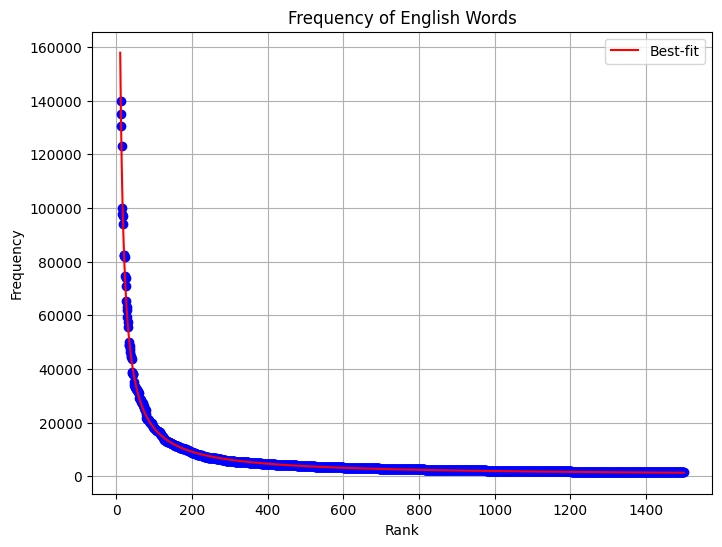

In [33]:
# convert data to dataframe
df = pd.read_csv("https://raw.githubusercontent.com/anthoak13/HNR-1303-F24/F25/unit-03/03-10-problem/english_words.txt", sep ="\t")

print(df.head())

# define arrays for the data
xdata = df['Rank'][10:]
ydata = df['Frequency'][10:]

# Define the best-fit function (model)
model = lambda x, A, n, B: A / (x+ B)**n

# Fit the model to the data
guess = [10000, 1, 1]  # initial guess for A, n, and B. Guess A is large since when x is small, y is large
params, cov = curve_fit(model, xdata, ydata, p0=guess)
print(f"The fitted parameters are A = {params[0]:.4f}, n = {params[1]:.4f}, B = {params[2]:.4f}")

# Generate the best-fit line using the fitted parameters
xmodel = np.linspace(10, 1500, 10000)
ymodel = model(xmodel, *params)

# plot data and the best-fit function on the same graph
fig = plt.figure(figsize=(8,6))
plt.title("Frequency of English Words")
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.grid(which='both', axis='both')
plt.plot(xdata, ydata, 'bo') #plot data
plt.plot(xmodel, ymodel, 'r-', label='Best-fit')
plt.legend()
plt.show()

## Exercise 6
Fill in the following table with the prediction of your model from Exercise 6. You can use your graph or you can calculate your prediction with your model. **As the rank of the word increases how does the accuracy of our model change? Around what rank does our new model start underpredicting the frequency of words?**


|Word|Rank|Frequency|Predicted Frequency|% Difference|
|---|---|---|---|---|
|I|10|172807| 173615.30 |0.47
|love|147|12071|12346.97  |2.29
|every|166|10852| 10965.54 |1.05
|dog|1335|1572| 1436.07 |-8.65


With the new model, we have a more accurate prediction across our test words. We can see the model start under-predicting somewhere between rank 166 and 1335, close to 450. 

In [39]:
# You can do this "by hand" for each word, I am going to speed it up using some lists
ranks = [9, 146, 165, 1334, 450]
for rank in ranks:
    word = df['Word'][rank]
    fmodel = model(rank, *params)
    frequency = df['Frequency'][rank]
    print(f" At rank {rank}, the word is \"{word}\" and its predicted frequency is {fmodel:.2f} (% diff: {100*(fmodel-frequency)/frequency:.2f}%)")

 At rank 9, the word is "I" and its predicted frequency is 173615.30 (% diff: 0.47%)
 At rank 146, the word is "love" and its predicted frequency is 12346.97 (% diff: 2.29%)
 At rank 165, the word is "every" and its predicted frequency is 10965.54 (% diff: 1.05%)
 At rank 1334, the word is "dog" and its predicted frequency is 1436.07 (% diff: -8.65%)
 At rank 450, the word is "call" and its predicted frequency is 4136.33 (% diff: 0.35%)
